2026-09-14 (월) - 바뀐 블로그 내용

### STEP 01. 실행 환경 확인

In [94]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, sklearn
from IPython.display import display

print("Python:", sys.executable)
print("Version:", sys.version.split()[0])
print("Working directory:", Path.cwd())
print("pandas / numpy / sklearn:", pd.__version__, np.__version__, sklearn.__version__)

Python: c:\dev\llm-data-analysis-course\.venv\Scripts\python.exe
Version: 3.14.6
Working directory: c:\dev\llm-data-analysis-course\notebooks
pandas / numpy / sklearn: 3.0.5 2.5.2 1.9.0


### STEP 02. Titanic 데이터 확보와 로딩

In [95]:
def get_project_root(start_path: Path | None = None) -> Path:

    current = (start_path or Path.cwd()).resolve()

    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")

project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"

if not data_path.is_file():
    raise FileNotFoundError(
        f"{data_path}\n저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )

df = pd.read_csv(data_path)
print("shape:", df.shape)
display(df.head())

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### STEP 03. 데이터 구조와 품질의 첫인상 확인

In [96]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_rate": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(dropna=False),
})

display(quality)
display(df.describe(include="number").T)

for c in ["Survived", "Pclass", "Sex", "Embarked"]:
    print("\n", c)
    display(df[c].value_counts(dropna=False).rename("count").to_frame())

,dtype,missing,missing_rate,nunique
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,89
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



 Survived


,count
Survived,
0,549
1,342



 Pclass


,count
Pclass,
3,491
1,216
2,184



 Sex


,count
Sex,
male,577
female,314



 Embarked


,count
Embarked,
S,644
C,168
Q,77
NaN,2


### STEP 04. 분석 문제와 Target 정의

In [97]:
TARGET = "Survived"
print(df[TARGET].value_counts().sort_index())
print({"task": "binary_classification", "target": TARGET, "positive_class": 1})

Survived
0    549
1    342
Name: count, dtype: int64
{'task': 'binary_classification', 'target': 'Survived', 'positive_class': 1}


### STEP 05. 결측치 처리

In [98]:
df_work = df.copy()
age_median_for_eda = df_work["Age"].median()
embarked_mode_for_eda = df_work["Embarked"].mode(dropna=True).iloc[0]
df_work["Age"] = df_work["Age"].fillna(age_median_for_eda)
df_work["Embarked"] = df_work["Embarked"].fillna(embarked_mode_for_eda)

print("EDA Age median:", age_median_for_eda)
print("EDA Embarked mode:", embarked_mode_for_eda)

display(df_work[["Age", "Embarked", "Cabin"]].isna().sum().to_frame("missing"))

EDA Age median: 28.0
EDA Embarked mode: S


,missing
Age,0
Embarked,0
Cabin,687


### STEP 06. 불필요한 컬럼 검토

In [99]:
column_policy = pd.DataFrame({
    "column": ["PassengerId", "Name", "Ticket", "Cabin"],
    "default_policy": ["exclude", "derive_or_defer", "derive_or_defer", "derive_or_defer"],
})

display(column_policy)

,column,default_policy
0,PassengerId,exclude
1,Name,derive_or_defer
2,Ticket,derive_or_defer
3,Cabin,derive_or_defer


In [100]:
candidate_cols = ["PassengerId", "Name", "Ticket", "Cabin"]
existing_cols = [c for c in candidate_cols if c in df_work.columns]

for col in existing_cols:
    print(f"\n[{col}] dtype={df_work[col].dtype}, nunique={df_work[col].nunique()}, "
          f"missing={df_work[col].isna().sum()}")
    print(df_work[col].dropna().astype(str).head(5).tolist())


[PassengerId] dtype=int64, nunique=891, missing=0
['1', '2', '3', '4', '5']

[Name] dtype=str, nunique=891, missing=0
['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry']

[Ticket] dtype=str, nunique=681, missing=0
['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450']

[Cabin] dtype=str, nunique=147, missing=687
['C85', 'C123', 'E46', 'G6', 'C103']


### STEP 07. 범주형 데이터 변환

In [101]:
df_encoded = df_work.copy()
df_encoded = pd.get_dummies(df_encoded, columns=["Sex", "Embarked"], dtype=int)
display(df_encoded.filter(regex="^(Sex_|Embarked_)").head())

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1,0,0,1
1,1,0,1,0,0
2,1,0,0,0,1
3,1,0,0,0,1
4,0,1,0,0,1


### STEP 08. 시각화와 기본 패턴 확인

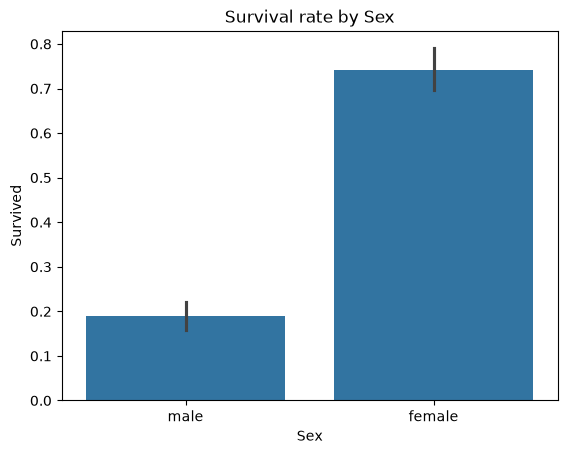

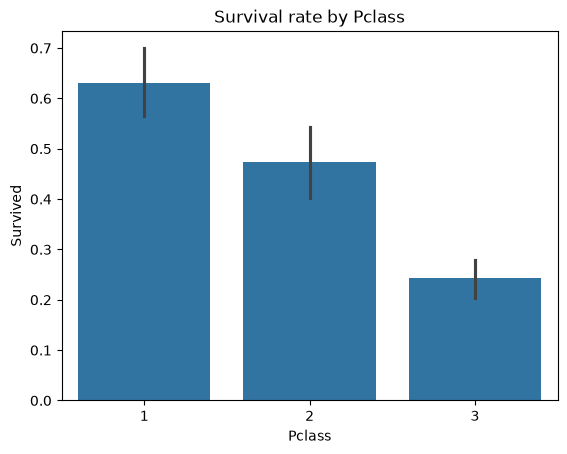

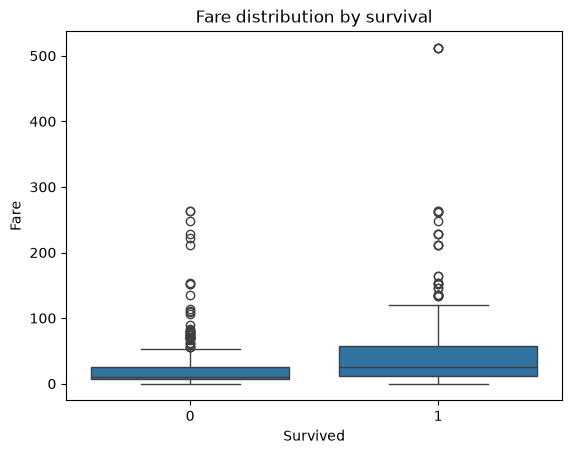

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
sns.barplot(data=df_work, x="Sex", y="Survived", ax=ax)
ax.set_title("Survival rate by Sex")
plt.show()
fig, ax = plt.subplots()
sns.barplot(data=df_work, x="Pclass", y="Survived", ax=ax)
ax.set_title("Survival rate by Pclass")
plt.show()
fig, ax = plt.subplots()
sns.boxplot(data=df_work, x="Survived", y="Fare", ax=ax)
ax.set_title("Fare distribution by survival")
ax.set_xlabel("Survived")
ax.set_ylabel("Fare")

plt.show()

### STEP 09. 기초 통계와 EDA

In [103]:
display(df_work.groupby("Sex").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))
display(df_work.groupby("Pclass").agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))
display(df_work.groupby(["Sex", "Pclass"]).agg(rows=("Survived", "size"), survival_rate=("Survived", "mean")))

,rows,survival_rate
Sex,,
female,314,0.742038
male,577,0.188908


,rows,survival_rate
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


rows  survival_rate
Sex    Pclass                     
female 1         94       0.968085
       2         76       0.921053
       3        144       0.500000
male   1        122       0.368852
       2        108       0.157407
       3        347       0.135447

In [104]:
from scipy import stats
survived = df_work.loc[df_work["Survived"] == 1, "Fare"]
not_survived = df_work.loc[df_work["Survived"] == 0, "Fare"]
t_stat, p_value = stats.ttest_ind(survived, not_survived, equal_var=False)

print("survived Fare mean:", round(survived.mean(), 2), " n =", survived.shape[0])
print("not survived Fare mean:", round(not_survived.mean(), 2), " n =", not_survived.shape[0])
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.3e}")

survived Fare mean: 48.4  n = 342
not survived Fare mean: 22.12  n = 549
t-statistic: 6.8391
p-value: 2.699e-11


### STEP 10. Feature 설계

In [105]:
feature_demo = df_work.copy()
feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1
feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)
display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


In [106]:
# STEP 10에서 결정한 Feature를 직접 생성
model_source = df.copy()

# 가족 수 = 본인 + 형제/배우자 + 부모/자녀
model_source["FamilySize"] = (
    model_source["SibSp"]
    + model_source["Parch"]
    + 1
)

# 혼자 탑승 여부
model_source["IsAlone"] = (
    model_source["FamilySize"] == 1
).astype(int)

display(
    model_source[
        ["SibSp", "Parch", "FamilySize", "IsAlone"]
    ].head()
)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [107]:
# 모델에 사용할 Feature
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

print("전체 데이터")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .rename("ratio")
     .to_frame()
)

print("학습 데이터")
display(
    y_train.value_counts(normalize=True)
           .sort_index()
           .rename("train_ratio")
           .to_frame()
)

print("테스트 데이터")
display(
    y_test.value_counts(normalize=True)
          .sort_index()
          .rename("test_ratio")
          .to_frame()
)

X: (891, 9)
y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

train: (712, 9) (712,)
test : (179, 9) (179,)
전체 데이터


,ratio
Survived,
0,0.616162
1,0.383838


학습 데이터


,train_ratio
Survived,
0,0.616573
1,0.383427


테스트 데이터


,test_ratio
Survived,
0,0.614525
1,0.385475


### STEP 11. 학습/테스트 데이터 준비
#### 11-1. 원본 df에서 모델링용 데이터 만들기

In [108]:
model_source = df.copy()

model_source["FamilySize"] = (
    model_source["SibSp"] + model_source["Parch"] + 1
)

model_source["IsAlone"] = (
    model_source["FamilySize"] == 1
).astype(int)

#### 
11-2. 사용할 Feature 직접 작성

In [109]:
raw_input_columns = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"
]

feature_columns = raw_input_columns + ["FamilySize", "IsAlone"]
numeric_features = [
    "Age", "SibSp", "Parch", "Fare", "FamilySize"
]

categorical_features = [
    "Pclass", "Sex", "Embarked", "IsAlone"
]

#### 11-3. X와 y 만들기

In [110]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

#### 11-4. Train/Test 분리

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

### STEP 12. 전처리를 하나씩 직접 실행하기
#### STEP 12-1. 숫자형 결측치 처리

In [112]:
from sklearn.impute import SimpleImputer
numeric_imputer = SimpleImputer(strategy="median")
X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

#### STEP 12-2. 범주형 결측치 처리

In [113]:
categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat_imputed = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[categorical_features]),
    columns=categorical_features,
    index=X_train.index,
)

X_test_cat_imputed = pd.DataFrame(
    categorical_imputer.transform(X_test[categorical_features]),
    columns=categorical_features,
    index=X_test.index,
)

#### STEP 12-3. One-Hot Encoding

In [114]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)

X_train_cat_encoded_array = encoder.fit_transform(X_train_cat_imputed)
X_test_cat_encoded_array = encoder.transform(X_test_cat_imputed)
encoded_feature_names = encoder.get_feature_names_out(categorical_features)
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded_array,
    columns=encoded_feature_names,
    index=X_train.index,
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded_array,
    columns=encoded_feature_names,
    index=X_test.index,
)

#### STEP 12-4. 정규화와 표준화 구분

In [115]:
from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()
minmax_preview = pd.DataFrame(
    minmax_demo.fit_transform(
        X_train_num_imputed[["Age", "Fare"]]
    ),

    columns=["Age_minmax", "Fare_minmax"],
    index=X_train.index,
)

display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.352852,0.110272
481,0.352852,0.000000
527,0.352852,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


#### STEP 12-5. StandardScaler로 실제 표준화

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_imputed),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num_imputed),
    columns=numeric_features,
    index=X_test.index,
)

#### STEP 12-6. 숫자형과 범주형 데이터 결합

In [117]:
X_train_ready = pd.concat(
    [X_train_num_scaled, X_train_cat_encoded],
    axis=1,
)

X_test_ready = pd.concat(
    [X_test_num_scaled, X_test_cat_encoded],
    axis=1,
)

In [118]:
print("X_train_ready:", X_train_ready.shape)
print("X_test_ready :", X_test_ready.shape)
print("missing train:", X_train_ready.isna().sum().sum())
print("missing test :", X_test_ready.isna().sum().sum())

X_train_ready: (712, 15)
X_test_ready : (179, 15)
missing train: 0
missing test : 0


#### STEP 12-7. Logistic Regression Baseline 학습

In [120]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

baseline_model.fit(X_train_ready, y_train);

### STEP 13. 성능 평가와 Confusion Matrix

In [121]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

baseline_pred = baseline_model.predict(X_test_ready)
print("accuracy :", round(accuracy_score(y_test, baseline_pred), 4))
print("precision:", round(precision_score(y_test, baseline_pred), 4))
print("recall   :", round(recall_score(y_test, baseline_pred), 4))
print("f1       :", round(f1_score(y_test, baseline_pred), 4))

accuracy : 0.8156
precision: 0.8103
recall   : 0.6812
f1       : 0.7402


In [122]:
cm = confusion_matrix(y_test, baseline_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(cm)
print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

[[99 11]
 [22 47]]
{'TN': np.int64(99), 'FP': np.int64(11), 'FN': np.int64(22), 'TP': np.int64(47)}


### STEP 14. 추가 모델 — Random Forest

In [123]:
from sklearn.ensemble import RandomForestClassifier

additional_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

additional_model.fit(X_train_ready, y_train)
additional_pred = additional_model.predict(X_test_ready)

### STEP 15. 모델 비교와 최종 선택

In [124]:
model_compare = pd.DataFrame([

    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "f1": f1_score(y_test, baseline_pred),
    },

    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, additional_pred),
        "f1": f1_score(y_test, additional_pred),
    },
])

display(model_compare)

,model,accuracy,f1
0,Logistic Regression,0.815642,0.740157
1,Random Forest,0.810056,0.725806


In [125]:
FINAL_MODEL_CHOICE = "baseline"

if FINAL_MODEL_CHOICE == "baseline":
    final_model = baseline_model
    final_model_name = "Logistic Regression"

elif FINAL_MODEL_CHOICE == "random_forest":
    final_model = additional_model
    final_model_name = "Random Forest"

else:
    raise ValueError("baseline 또는 random_forest를 선택하세요.")

### Part 3. 저장·새 입력 예측·서비스
#### STEP 16. 전처리 객체와 모델 저장

In [126]:
import json
import joblib

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)
bundle_path = models_dir / "titanic_model_bundle.joblib"
contract_path = models_dir / "titanic_model_contract.json"

model_bundle = {
    "numeric_imputer": numeric_imputer,
    "categorical_imputer": categorical_imputer,
    "encoder": encoder,
    "scaler": scaler,
    "model": final_model,
}

joblib.dump(model_bundle, bundle_path)

['C:\\dev\\llm-data-analysis-course\\models\\titanic_model_bundle.joblib']

In [127]:
model_contract = {
    "task": "binary_classification",
    "target": "Survived",
    "positive_class": 1,
    "raw_input_columns": raw_input_columns,
    "model_feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "prepared_feature_columns": X_train_ready.columns.tolist(),
    "derived_features": ["FamilySize", "IsAlone"],
    "scaling": "StandardScaler",
    "final_estimator": type(final_model).__name__,
}

In [129]:
import json
from pathlib import Path

project_root = Path.cwd()

# Notebook을 notebooks 폴더에서 실행하는 경우
if project_root.name == "notebooks":
    project_root = project_root.parent

contract_path = project_root / "models" / "titanic_model_contract.json"

contract_path.parent.mkdir(parents=True, exist_ok=True)

contract_path.write_text(
    json.dumps(
        model_contract,
        ensure_ascii=False,
        indent=2,
        ),
        encoding="utf-8",
)

print("Contract 저장 완료:")
print(contract_path.resolve())
print("파일 존재:", contract_path.exists())

Contract 저장 완료:
C:\dev\llm-data-analysis-course\models\titanic_model_contract.json
파일 존재: True
